**This notebook is where we implement our LASSO model**

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import KFold, train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler # Though factors are already custom standardized

In [5]:
# --- 1. Load Data ---
# Adjust path as necessary
processed_data_path = 'C:/Users/Admin/projects/Omer_Sen_Thesis_Quantitative_Finance/02_Data_Collection_and_Preperation/Proccessed_Data/sp500_factors_final_for_modeling.parquet' 
# This file should have factors imputed and standardized to [-1,1], and target_ret_t_plus_1

try:
    df = pd.read_parquet(processed_data_path)
    print(f"Successfully loaded data from {processed_data_path}. Shape: {df.shape}")
    # Ensure 'date' is datetime
    df['date'] = pd.to_datetime(df['date'])
except FileNotFoundError:
    print(f"Error: File not found at {processed_data_path}. Please ensure the path is correct and the file exists.")
    df = None
except Exception as e:
    print(f"An error occurred loading the Parquet file: {e}")
    df = None

if df is not None:
    # --- Define Factor Columns (Predictors X) and Target (y) ---
    # Assuming 'target_ret_t_plus_1' is the target variable
    # and other non-identifier, non-target columns are factors.
    
    all_columns = df.columns.tolist()
    known_identifiers_and_target = [
        'permno', 'date', 'ret'
       
    ]

    identifier_cols = ['permno', 'date', 'ret', 'target_ret_t_plus_1'] # Core identifiers and target
    # Add other known non-factor columns from your specific df
    
    non_predictor_cols = identifier_cols 
    
    factor_columns = [col for col in df.columns if col not in non_predictor_cols and df[col].dtype == 'float64']
    

    print(f"Identified {len(factor_columns)} predictor (factor) columns.")
    if not factor_columns or len(factor_columns) < 150: # Check if a reasonable number of factors were found
        print("Warning: Number of identified factor columns seems low. Please verify the column exclusion logic.")
        print("First few columns assumed to be factors:", [col for col in df.columns if col not in non_predictor_cols][:5])


    TARGET_COL = 'target_ret_t_plus_1'

    # Drop rows where target is NaN (already done in previous notebook, but good check)
    df.dropna(subset=[TARGET_COL], inplace=True)
    # Also drop rows where any of the chosen factor_columns are NaN, if any slipped through imputation
    # (Cross-sectional rank should handle most, but good to be sure)
    df.dropna(subset=factor_columns, inplace=True) 
    print(f"Shape after dropping any remaining NaNs in target or factors: {df.shape}")


Successfully loaded data from C:/Users/Admin/projects/Omer_Sen_Thesis_Quantitative_Finance/02_Data_Collection_and_Preperation/Proccessed_Data/sp500_factors_final_for_modeling.parquet. Shape: (344511, 156)
Identified 152 predictor (factor) columns.
Shape after dropping any remaining NaNs in target or factors: (344511, 156)


In [6]:
# --- 2. Define Date Ranges ---
print("\n--- Defining Date Ranges ---")
train_start_date = pd.to_datetime('1965-01-31')
train_end_date = pd.to_datetime('1989-12-31') # Initial training
    
validation_start_date = pd.to_datetime('1990-01-31')
validation_end_date = pd.to_datetime('2004-12-31') # Validation of hyperparameter tuning STRATEGY
    
oos_test_start_date = pd.to_datetime('2005-01-31')
oos_test_end_date = pd.to_datetime('2023-12-31') # Final OOS testing

print(f"Initial Training: {train_start_date.date()} to {train_end_date.date()}")
print(f"Validation of Strategy: {validation_start_date.date()} to {validation_end_date.date()}")
print(f"Out-of-Sample Test: {oos_test_start_date.date()} to {oos_test_end_date.date()}")



--- Defining Date Ranges ---
Initial Training: 1965-01-31 to 1989-12-31
Validation of Strategy: 1990-01-31 to 2004-12-31
Out-of-Sample Test: 2005-01-31 to 2023-12-31


In [7]:
 # --- 3. Split Data (Initial Split for Training and Validation of Strategy) ---
print("\n--- Splitting Data (Initial Train & Validation Strategy Sets) ---")
train_df = df[(df['date'] >= train_start_date) & (df['date'] <= train_end_date)].copy()
validation_strategy_df = df[(df['date'] >= validation_start_date) & (df['date'] <= validation_end_date)].copy()

print(f"Initial Training Set: {len(train_df)} observations ({train_df['date'].min().date()} to {train_df['date'].max().date()})")
print(f"Validation Strategy Set: {len(validation_strategy_df)} observations ({validation_strategy_df['date'].min().date()} to {validation_strategy_df['date'].max().date()})")



--- Splitting Data (Initial Train & Validation Strategy Sets) ---
Initial Training Set: 148018 observations (1965-01-31 to 1989-12-31)
Validation Strategy Set: 88892 observations (1990-01-31 to 2004-12-31)


In [8]:
# --- 4. Prepare X and y for these initial sets ---
if not train_df.empty:
    X_train_initial = train_df[factor_columns]
    y_train_initial = train_df[TARGET_COL]
else:
    print("Initial training set is empty. Cannot proceed with X_train_initial, y_train_initial.")
    X_train_initial, y_train_initial = None, None

if not validation_strategy_df.empty:
    X_validation_strategy = validation_strategy_df[factor_columns]
    y_validation_strategy = validation_strategy_df[TARGET_COL]
else:
    print("Validation strategy set is empty. Cannot proceed with X_validation_strategy, y_validation_strategy.")
    X_validation_strategy, y_validation_strategy = None, None
        

In [9]:
# --- 5. Initial LASSO Model Training & Hyperparameter (λ) Strategy Validation ---
    # This part will be more involved. We'll start by setting up the structure.
    
print("\n--- Setting up for LASSO Hyperparameter (λ) Strategy Validation ---")
if X_train_initial is not None and X_validation_strategy is not None:
    # Define a range of λ (alpha) values for LassoCV
    # These are common ranges, can be adjusted.
    alphas_to_try = np.logspace(-5, 1, 100) 

    # We will simulate the yearly re-tuning process on the validation_strategy_df period.
    # For now, let's just confirm the setup. The actual loop for yearly CV and prediction
    # will be part of the next step.
        
    print(f"X_train_initial shape: {X_train_initial.shape}")
    print(f"y_train_initial shape: {y_train_initial.shape}")
    print(f"X_validation_strategy shape: {X_validation_strategy.shape}")
    print(f"y_validation_strategy shape: {y_validation_strategy.shape}")
    print(f"Defined {len(alphas_to_try)} alpha values for LassoCV.")
        
    # Example: Fit LassoCV on the *initial* training data to see how it works
    # This helps select a range of alphas and confirms k-fold CV runs.
    # Note: For the actual dynamic process, CV is done on the *expanding window* each year.
    print("\nPerforming a sample LassoCV fit on the initial training data (1965-1989)...")
    # TimeSeriesSplit is often better for financial time series CV if observations are ordered and dependent.
    # However, for cross-sectional ranking and then pooling, KFold might be what GKX imply 
    # if "within the training sample of each period t" means shuffling the pooled panel data for that period.
    # Let's use KFold for now as it's simpler and often used if time dependence is handled by other means (like yearly refit).
        
    # Use TimeSeriesSplit for cross-validation to respect temporal order
    # n_splits should be appropriate for the size of data in each expanding window. 
    # For the initial training set, let's use 5 splits.
    # If your data is already month-permno rows, ensure it's sorted by date for TimeSeriesSplit.
    # The data should be sorted by date primarily for TimeSeriesSplit to work as expected.
        
    cv_splitter = TimeSeriesSplit(n_splits=5)
        
    lasso_cv_initial = LassoCV(alphas=alphas_to_try, cv=cv_splitter, random_state=42, max_iter=10000, tol=1e-3)
        
    # Ensure X_train_initial and y_train_initial are sorted by date if not already
    # (df was sorted before split, so train_df should maintain that order if sliced correctly)
    # For LassoCV with TimeSeriesSplit, the input data should be chronologically ordered.
    # Since train_df is a slice, it should retain the overall sort order from df.
        
    lasso_cv_initial.fit(X_train_initial, y_train_initial)
        
    print(f"LassoCV on initial train data - Optimal alpha (λ): {lasso_cv_initial.alpha_}")
        
    # Evaluate on the *first year* of the validation_strategy set (e.g., 1990)
    # This is a simplified check. Proper validation of the strategy involves the loop.
    if not validation_strategy_df[validation_strategy_df['date'].dt.year == 1990].empty:
        X_val_1990 = validation_strategy_df[validation_strategy_df['date'].dt.year == 1990][factor_columns]
        y_val_1990 = validation_strategy_df[validation_strategy_df['date'].dt.year == 1990][TARGET_COL]
            
        if not X_val_1990.empty:
            predictions_1990 = lasso_cv_initial.predict(X_val_1990)
            mse_1990 = mean_squared_error(y_val_1990, predictions_1990)
            r2_1990 = r2_score(y_val_1990, predictions_1990) # Out-of-sample R^2 can be negative
            print(f"Performance on 1990 (validation set) using model from 1965-1989 with CV-tuned λ:")
            print(f"  MSE: {mse_1990:.6f}")
            print(f"  OOS R2: {r2_1990:.4f}")
        else:
            print("No data for 1990 in validation_strategy_df to evaluate.")
    else:
        print("Year 1990 not found in validation_strategy_df for initial check.")
            
else:
    print("Cannot proceed with LASSO setup as training or validation data is missing.")


--- Setting up for LASSO Hyperparameter (λ) Strategy Validation ---
X_train_initial shape: (148018, 152)
y_train_initial shape: (148018,)
X_validation_strategy shape: (88892, 152)
y_validation_strategy shape: (88892,)
Defined 100 alpha values for LassoCV.

Performing a sample LassoCV fit on the initial training data (1965-1989)...
LassoCV on initial train data - Optimal alpha (λ): 0.0001232846739442066
Performance on 1990 (validation set) using model from 1965-1989 with CV-tuned λ:
  MSE: 0.013201
  OOS R2: -0.0018


In [11]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt # For plotting chosen alphas


--- Starting Hyperparameter (λ) Strategy Validation Loop (Predicting for 1990-2004) ---
Using fixed initial lambda: 0.0001232846739442066

Processing for year to predict: 1990
  Strategy 1 (Adaptive λ): Training on 148018 obs up to 1989-12-31
    Adaptive λ for predicting 1990: 0.000123
  Strategy 2 (Fixed Initial λ = 0.000123): Training on 148018 obs

Processing for year to predict: 1991
  Strategy 1 (Adaptive λ): Training on 153978 obs up to 1990-12-31
    Adaptive λ for predicting 1991: 0.000123
  Strategy 2 (Fixed Initial λ = 0.000123): Training on 153978 obs

Processing for year to predict: 1992
  Strategy 1 (Adaptive λ): Training on 159946 obs up to 1991-12-31
    Adaptive λ for predicting 1992: 0.000107
  Strategy 2 (Fixed Initial λ = 0.000123): Training on 159946 obs

Processing for year to predict: 1993
  Strategy 1 (Adaptive λ): Training on 165921 obs up to 1992-12-31
    Adaptive λ for predicting 1993: 0.000107
  Strategy 2 (Fixed Initial λ = 0.000123): Training on 165921 o

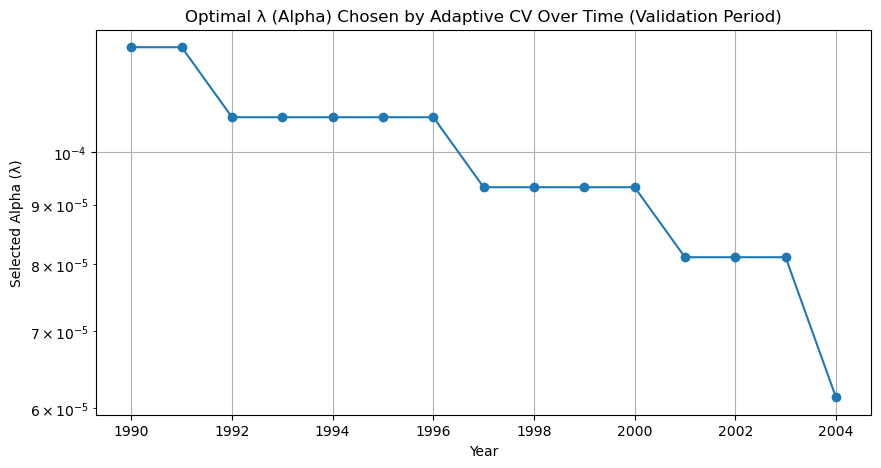

Fixed Initial λ Strategy (1990-2004):
  Overall MSE: 0.011026
  Overall OOS R2 (vs initial train mean): 0.0040

Validation of hyperparameter strategy complete. Review metrics to decide on the best approach for the OOS test period.


In [12]:
# --- 5. Hyperparameter (λ) Strategy Validation Loop (1990-2004) ---
print("\n--- Starting Hyperparameter (λ) Strategy Validation Loop (Predicting for 1990-2004) ---")

validation_predict_years = range(validation_start_date.year, validation_end_date.year + 1)

# Store results for each strategy
results_adaptive_cv = [] # List of (actual_y, predicted_y) pairs or DataFrames
alphas_chosen_adaptive = [] # Store chosen alpha for each year

results_fixed_initial_lambda = []
lambda_fixed_initial = lasso_cv_initial.alpha_ # λ from 1965-1989 CV
print(f"Using fixed initial lambda: {lambda_fixed_initial}")

# Define alphas for LassoCV if not already global
alphas_to_try = np.logspace(-5, 1, 100) 
cv_splitter = TimeSeriesSplit(n_splits=5)

for year_to_predict in validation_predict_years:
    print(f"\nProcessing for year to predict: {year_to_predict}")
    
    # 1. Define current expanding training window
    current_train_end_date = pd.to_datetime(f"{year_to_predict-1}-12-31")
    current_train_df = df[(df['date'] >= train_start_date) & (df['date'] <= current_train_end_date)].copy()
    
    # 2. Define current test window (the year we are predicting for)
    current_test_start_date = pd.to_datetime(f"{year_to_predict}-01-31")
    current_test_end_date = pd.to_datetime(f"{year_to_predict}-12-31")
    current_test_df = df[(df['date'] >= current_test_start_date) & (df['date'] <= current_test_end_date)].copy()

    if current_train_df.empty or current_test_df.empty:
        print(f"Skipping {year_to_predict}: not enough data for train or test.")
        continue

    X_current_train = current_train_df[factor_columns]
    y_current_train = current_train_df[TARGET_COL]
    X_current_test = current_test_df[factor_columns]
    y_current_test_actual = current_test_df[TARGET_COL]

    # --- Strategy 1: Adaptive λ (Yearly CV) ---
    print(f"  Strategy 1 (Adaptive λ): Training on {len(X_current_train)} obs up to {current_train_end_date.date()}")
    lasso_cv_adaptive = LassoCV(alphas=alphas_to_try, cv=cv_splitter, random_state=year_to_predict, max_iter=10000, tol=1e-3, n_jobs=-1) # Use n_jobs=-1 for parallel
    lasso_cv_adaptive.fit(X_current_train, y_current_train)
    selected_alpha_adaptive = lasso_cv_adaptive.alpha_
    alphas_chosen_adaptive.append({'year': year_to_predict, 'alpha': selected_alpha_adaptive})
    print(f"    Adaptive λ for predicting {year_to_predict}: {selected_alpha_adaptive:.6f}")
    
    # Train final model for this period with selected adaptive alpha
    model_adaptive = Lasso(alpha=selected_alpha_adaptive, random_state=year_to_predict, max_iter=10000, tol=1e-3)
    model_adaptive.fit(X_current_train, y_current_train)
    predictions_adaptive = model_adaptive.predict(X_current_test)
    results_adaptive_cv.append(pd.DataFrame({'date': current_test_df['date'], 
                                             'permno': current_test_df['permno'],
                                             'actual_ret': y_current_test_actual, 
                                             'predicted_ret_adaptive_cv': predictions_adaptive}))

    # --- Strategy 2: Fixed λ (from initial 1965-1989 training) ---
    print(f"  Strategy 2 (Fixed Initial λ = {lambda_fixed_initial:.6f}): Training on {len(X_current_train)} obs")
    model_fixed_initial = Lasso(alpha=lambda_fixed_initial, random_state=year_to_predict, max_iter=10000, tol=1e-3)
    model_fixed_initial.fit(X_current_train, y_current_train)
    predictions_fixed_initial = model_fixed_initial.predict(X_current_test)
    results_fixed_initial_lambda.append(pd.DataFrame({'date': current_test_df['date'],
                                                      'permno': current_test_df['permno'],
                                                      'actual_ret': y_current_test_actual, # actuals are same
                                                      'predicted_ret_fixed_initial': predictions_fixed_initial}))
    # (Add Strategy 3 here if you implement it)

# --- Consolidate and Evaluate Results for Validation Period ---
print("\n--- Evaluating Performance on Validation Period (1990-2004) ---")

if results_adaptive_cv:
    df_results_adaptive = pd.concat(results_adaptive_cv, ignore_index=True)
    mse_adaptive = mean_squared_error(df_results_adaptive['actual_ret'], df_results_adaptive['predicted_ret_adaptive_cv'])
    # For OOS R2, use the mean of the *initial* training period (1965-1989) as the benchmark denominator
    # This is a simplification; a more rigorous OOS R2 would use the mean from the *expanding* training window for each prediction.
    # However, for a single summary R2 for the validation period, using the overall mean of y_train_initial is often done.
    mean_initial_train_ret = y_train_initial.mean() 
    r2_oos_adaptive = 1 - (np.sum((df_results_adaptive['actual_ret'] - df_results_adaptive['predicted_ret_adaptive_cv'])**2) / 
                           np.sum((df_results_adaptive['actual_ret'] - mean_initial_train_ret)**2))
    print(f"Adaptive CV Strategy (1990-2004):")
    print(f"  Overall MSE: {mse_adaptive:.6f}")
    print(f"  Overall OOS R2 (vs initial train mean): {r2_oos_adaptive:.4f}")

    # Plot chosen alphas over time for adaptive strategy
    df_alphas = pd.DataFrame(alphas_chosen_adaptive)
    plt.figure(figsize=(10,5))
    plt.plot(df_alphas['year'], df_alphas['alpha'], marker='o')
    plt.title('Optimal λ (Alpha) Chosen by Adaptive CV Over Time (Validation Period)')
    plt.xlabel('Year')
    plt.ylabel('Selected Alpha (λ)')
    plt.yscale('log') # Alphas often vary over orders of magnitude
    plt.grid(True)
    plt.show()

if results_fixed_initial_lambda:
    df_results_fixed_initial = pd.concat(results_fixed_initial_lambda, ignore_index=True)
    mse_fixed_initial = mean_squared_error(df_results_fixed_initial['actual_ret'], df_results_fixed_initial['predicted_ret_fixed_initial'])
    r2_oos_fixed_initial = 1 - (np.sum((df_results_fixed_initial['actual_ret'] - df_results_fixed_initial['predicted_ret_fixed_initial'])**2) / 
                                np.sum((df_results_fixed_initial['actual_ret'] - mean_initial_train_ret)**2))
    print(f"Fixed Initial λ Strategy (1990-2004):")
    print(f"  Overall MSE: {mse_fixed_initial:.6f}")
    print(f"  Overall OOS R2 (vs initial train mean): {r2_oos_fixed_initial:.4f}")
    
# Further analysis (portfolio sorts, IC) would be done on these df_results DataFrames.
# For example, for portfolio sorts:
# df_results_adaptive['pred_quantile'] = df_results_adaptive.groupby('date')['predicted_ret_adaptive_cv'].transform(
#                                          lambda x: pd.qcut(x, 10, labels=False, duplicates='drop'))
# portfolio_returns_adaptive = df_results_adaptive.groupby(['date', 'pred_quantile'])['actual_ret'].mean().unstack()
# long_short_adaptive = portfolio_returns_adaptive[9] - portfolio_returns_adaptive[0] # Example: Decile 10 - Decile 1
# print(f"\nAdaptive CV - Mean Long-Short Portfolio Return (Decile 10-1): {long_short_adaptive.mean():.4%}")
# print(f"Adaptive CV - Sharpe Ratio Long-Short: {(long_short_adaptive.mean() / long_short_adaptive.std()) * np.sqrt(12):.2f}")

print("\nValidation of hyperparameter strategy complete. Review metrics to decide on the best approach for the OOS test period.")


**Portfolio Comparison**


--- Starting Portfolio Sort Analysis (Validation Period 1990-2004) ---

Evaluating strategy: Adaptive CV λ
  Long-Short Portfolio (Top 10.0% - Bottom 10.0%):
    Mean Monthly Return: 2.3182%
    Annualized Sharpe Ratio: 2.06

  Mean Monthly Returns for All 10 Quantile Portfolios (Adaptive CV λ):
    Quantile 1: -0.0062%
    Quantile 2: 0.5140%
    Quantile 3: 0.6763%
    Quantile 4: 0.9667%
    Quantile 5: 1.0997%
    Quantile 6: 1.2218%
    Quantile 7: 1.3844%
    Quantile 8: 1.6363%
    Quantile 9: 2.0206%
    Quantile 10: 2.3120%

Evaluating strategy: Fixed Initial λ
  Long-Short Portfolio (Top 10.0% - Bottom 10.0%):
    Mean Monthly Return: 2.3133%
    Annualized Sharpe Ratio: 2.02

  Mean Monthly Returns for All 10 Quantile Portfolios (Fixed Initial λ):
    Quantile 1: -0.0282%
    Quantile 2: 0.5596%
    Quantile 3: 0.6999%
    Quantile 4: 0.8980%
    Quantile 5: 1.1428%
    Quantile 6: 1.2394%
    Quantile 7: 1.3674%
    Quantile 8: 1.6571%
    Quantile 9: 2.0066%
    Quantile 

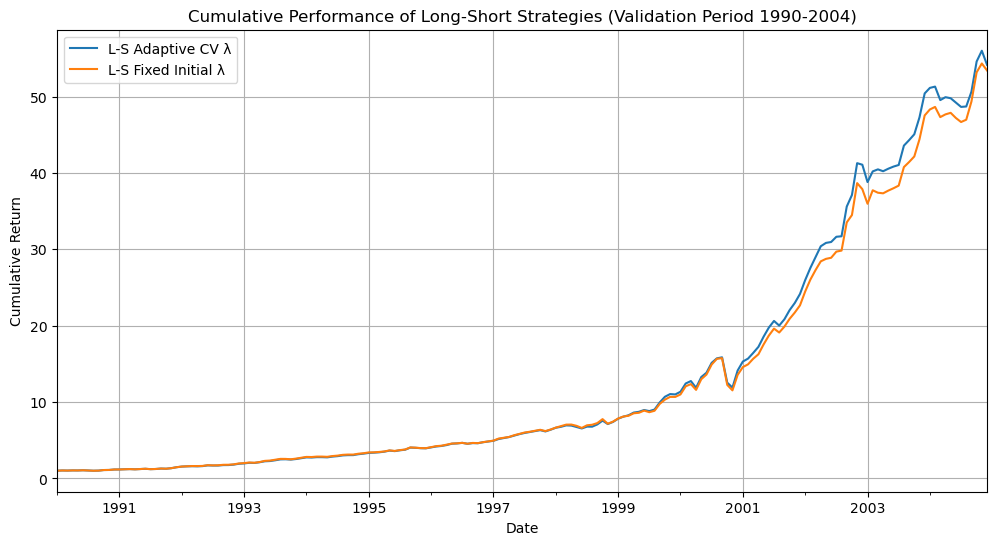


Portfolio sort analysis for the validation period complete.
Review the mean returns and Sharpe ratios to help decide which λ strategy to carry forward.


In [13]:
# We might need statsmodels for Fama-French regression later, but not for basic portfolio sorts
# import statsmodels.api as sm 

# --- Assume df_results_adaptive and df_results_fixed_initial DataFrames are available from the previous cell ---
# --- Also assume 'TARGET_COL' ('target_ret_t_plus_1') and 'ret' (actual realized return for t+1) are named consistently ---
# In the previous script, 'actual_ret' was used for the target in these result DataFrames.

print("\n--- Starting Portfolio Sort Analysis (Validation Period 1990-2004) ---")

N_QUANTILES = 10 # Deciles; change to 5 for quintiles if preferred

def evaluate_portfolio_strategy(df_results, pred_col_name, strategy_name):
    """
    Performs portfolio sorts and evaluates the long-short strategy.
    Assumes df_results has 'date', 'permno', 'actual_ret', and the specified pred_col_name.
    """
    if df_results is None or df_results.empty:
        print(f"Skipping portfolio evaluation for {strategy_name}: No results data provided.")
        return None

    print(f"\nEvaluating strategy: {strategy_name}")

    # Assign stocks to quantiles based on predictions for each date
    # Ensure predictions are not all identical within a date group, otherwise qcut fails or behaves unexpectedly.
    # 'duplicates="drop"' will assign fewer than N_QUANTILES if many predictions are identical.
    # 'duplicates="raise"' would alert you to this issue.
    try:
        df_results['pred_quantile'] = df_results.groupby('date')[pred_col_name].transform(
                                         lambda x: pd.qcut(x, N_QUANTILES, labels=False, duplicates='drop'))
    except ValueError as e:
        # This can happen if, for a given date, all predicted values are the same, making quantiles impossible.
        print(f"  Warning: Could not form quantiles for strategy '{strategy_name}' for at least one date. Error: {e}")
        print(f"  This might occur if LASSO selected no features (all predictions are intercept).")
        # Handle by trying to assign to a middle quantile or skipping those dates for this calc?
        # For now, we'll proceed, and portfolio_returns might have NaNs for such dates.
        # A more robust handling might involve checking unique prediction counts per date.
        # If all predictions are the same for a date, those stocks effectively form one group.
        
        # Fallback: if qcut fails, check if all predictions are identical for problematic dates
        # This is a simplified check.
        for date_group, group_data in df_results.groupby('date'):
            if group_data[pred_col_name].nunique() == 1:
                print(f"    For date {date_group.date()}, all predictions for '{strategy_name}' are identical: {group_data[pred_col_name].iloc[0]}")
        # For this analysis, we'll proceed, acknowledging qcut might have dropped some quantiles for certain dates.
        # If all predictions are 0 (e.g. no features selected), then this strategy is untestable via sorts.
        if df_results[pred_col_name].abs().sum() < 1e-9: # Check if essentially all predictions are zero
             print(f"  Warning: All predictions for '{strategy_name}' are zero or near-zero. Portfolio sort analysis will not be meaningful.")
             return None


    # Calculate equal-weighted portfolio returns for each quantile
    # 'actual_ret' column should contain the realized returns for the period t+1 that was predicted
    portfolio_returns = df_results.groupby(['date', 'pred_quantile'])['actual_ret'].mean().unstack()

    if portfolio_returns.empty or (N_QUANTILES -1 not in portfolio_returns.columns or 0 not in portfolio_returns.columns) :
        print(f"  Could not form meaningful quantile portfolios for {strategy_name}. This might be due to all predictions being identical or too few unique predictions per period.")
        # Check if specific quantiles are missing
        if not portfolio_returns.empty:
            if (N_QUANTILES - 1) not in portfolio_returns.columns:
                print(f"    Highest quantile ({N_QUANTILES-1}) is missing in portfolio_returns for {strategy_name}.")
            if 0 not in portfolio_returns.columns:
                print(f"    Lowest quantile (0) is missing in portfolio_returns for {strategy_name}.")
        return None


    # Long-Short portfolio (highest quantile - lowest quantile)
    # Ensure the quantile labels are 0 to N_QUANTILES-1
    long_portfolio = portfolio_returns[N_QUANTILES - 1]
    short_portfolio = portfolio_returns[0]
    long_short_returns = long_portfolio - short_portfolio
    
    # Performance Metrics for Long-Short
    mean_ls_return_monthly = long_short_returns.mean()
    std_ls_return_monthly = long_short_returns.std()
    
    # Annualized Sharpe Ratio (assuming risk-free rate is 0 for simplicity here)
    # For more rigor, you'd subtract the actual risk-free rate for each month.
    sharpe_ratio_annualized = (mean_ls_return_monthly / std_ls_return_monthly) * np.sqrt(12) if std_ls_return_monthly != 0 else 0
    
    print(f"  Long-Short Portfolio (Top {100/N_QUANTILES}% - Bottom {100/N_QUANTILES}%):")
    print(f"    Mean Monthly Return: {mean_ls_return_monthly:.4%}")
    print(f"    Annualized Sharpe Ratio: {sharpe_ratio_annualized:.2f}")
    
    # Print returns of all quantile portfolios for inspection
    print(f"\n  Mean Monthly Returns for All {N_QUANTILES} Quantile Portfolios ({strategy_name}):")
    mean_quantile_returns = portfolio_returns.mean().sort_index()
    for q, r in mean_quantile_returns.items():
        print(f"    Quantile {q+1}: {r:.4%}") # q is 0-indexed, so q+1 for display
        
    # You can also add Fama-French alpha calculation here later if desired
    # For now, we return the series of long-short returns for potential further analysis
    return long_short_returns.copy(), portfolio_returns.copy()

# --- Evaluate Adaptive CV Strategy ---
ls_returns_adaptive, quant_returns_adaptive = evaluate_portfolio_strategy(df_results_adaptive, 'predicted_ret_adaptive_cv', 'Adaptive CV λ')

# --- Evaluate Fixed Initial λ Strategy ---
ls_returns_fixed, quant_returns_fixed = evaluate_portfolio_strategy(df_results_fixed_initial, 'predicted_ret_fixed_initial', 'Fixed Initial λ')

# --- Direct Comparison (if both strategies yielded results) ---
if ls_returns_adaptive is not None and ls_returns_fixed is not None:
    print("\n--- Summary Comparison of Long-Short Strategies (Validation Period 1990-2004) ---")
    print(f"{'Metric':<30} {'Adaptive CV λ':<20} {'Fixed Initial λ':<20}")
    print("-" * 70)
    
    mean_adaptive = ls_returns_adaptive.mean()
    sharpe_adaptive = (mean_adaptive / ls_returns_adaptive.std()) * np.sqrt(12) if ls_returns_adaptive.std() !=0 else 0
    
    mean_fixed = ls_returns_fixed.mean()
    sharpe_fixed = (mean_fixed / ls_returns_fixed.std()) * np.sqrt(12) if ls_returns_fixed.std() !=0 else 0
    
    print(f"{'Mean Monthly L-S Return':<30} {mean_adaptive:<20.4%} {mean_fixed:<20.4%}")
    print(f"{'Annualized L-S Sharpe Ratio':<30} {sharpe_adaptive:<20.2f} {sharpe_fixed:<20.2f}")
    
    # You could also plot cumulative returns of the L-S strategies
    plt.figure(figsize=(12,6))
    if ls_returns_adaptive is not None:
        (1 + ls_returns_adaptive).cumprod().plot(label='L-S Adaptive CV λ', legend=True)
    if ls_returns_fixed is not None:
        (1 + ls_returns_fixed).cumprod().plot(label='L-S Fixed Initial λ', legend=True)
    plt.title('Cumulative Performance of Long-Short Strategies (Validation Period 1990-2004)')
    plt.ylabel('Cumulative Return')
    plt.xlabel('Date')
    plt.grid(True)
    plt.show()
else:
    print("\nCould not perform full comparison as one or both strategies did not yield sortable results.")

print("\nPortfolio sort analysis for the validation period complete.")
print("Review the mean returns and Sharpe ratios to help decide which λ strategy to carry forward.")

While the differences in the aggregate MSE/R² were marginal, the portfolio sort analysis shows:
Both strategies are effective at identifying stocks that will outperform/underperform.
The Adaptive CV λ strategy shows a consistent (albeit small) edge in terms of mean L-S return and annualized Sharpe ratio during the 1990-2004 validation period.
The plot of chosen λs showed that the optimal λ did change over time, suggesting that adapting it is a more robust approach.
Therefore, proceeding with the Adaptive CV λ strategy for the Out-of-Sample (OOS) test period (2005-2023) is a well-justified decision.


--- Starting LASSO Out-of-Sample (OOS) Test Period (Predicting for 2005-2023) ---
Using Adaptive CV λ Strategy (Yearly Re-tuning on Expanding Window)

Processing OOS for year to predict: 2005
  Training on 236910 obs from 1965-01-31 to 2004-12-31
    Optimal λ for predicting 2005: 0.000061, Selected Features: 90

Processing OOS for year to predict: 2006
  Training on 242751 obs from 1965-01-31 to 2005-12-31
    Optimal λ for predicting 2006: 0.000061, Selected Features: 90

Processing OOS for year to predict: 2007
  Training on 248548 obs from 1965-01-31 to 2006-12-31
    Optimal λ for predicting 2007: 0.000061, Selected Features: 86

Processing OOS for year to predict: 2008
  Training on 254315 obs from 1965-01-31 to 2007-12-31
    Optimal λ for predicting 2008: 0.000061, Selected Features: 87

Processing OOS for year to predict: 2009
  Training on 260067 obs from 1965-01-31 to 2008-12-31
    Optimal λ for predicting 2009: 0.000081, Selected Features: 78

Processing OOS for year to p

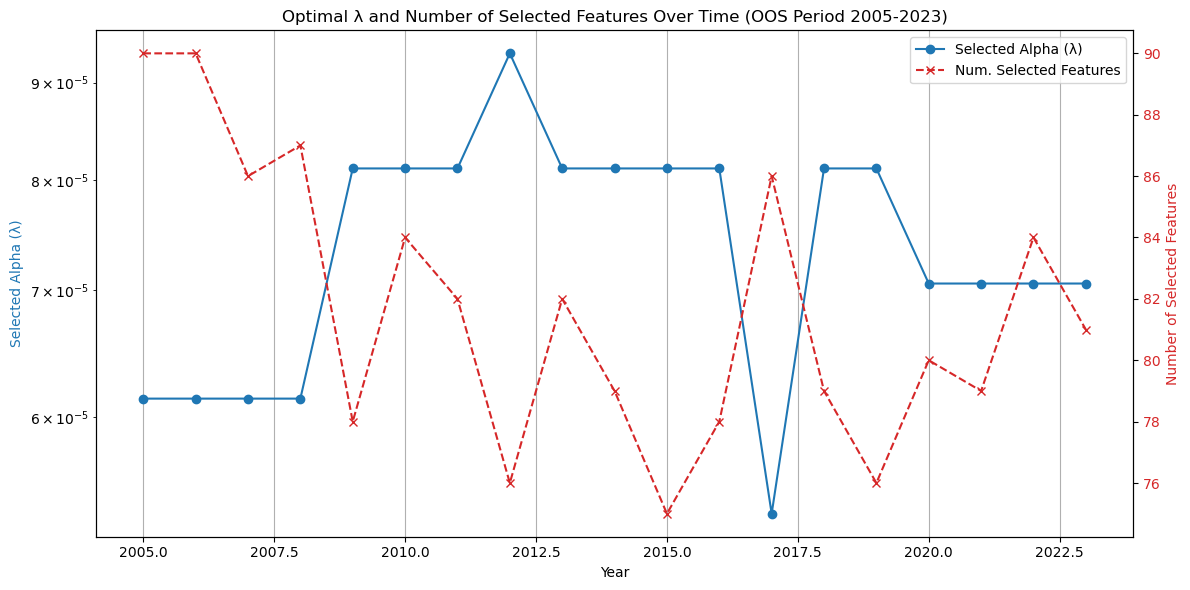


Evaluating strategy: Adaptive CV λ (OOS 2005-2023)
  Long-Short Portfolio (Top 10.0% - Bottom 10.0%):
    Mean Monthly Return: 0.5045%
    Annualized Sharpe Ratio: 0.43

  Mean Monthly Returns for All 10 Quantile Portfolios (Adaptive CV λ (OOS 2005-2023)):
    Quantile 1: 0.6307%
    Quantile 2: 0.7136%
    Quantile 3: 0.8913%
    Quantile 4: 0.9318%
    Quantile 5: 0.9227%
    Quantile 6: 1.0281%
    Quantile 7: 0.9670%
    Quantile 8: 1.0529%
    Quantile 9: 1.0631%
    Quantile 10: 1.1352%

--- Summary for OOS Long-Short Strategy (2005-2023) ---
  Mean Monthly L-S Return: 0.5045%
  Annualized L-S Sharpe Ratio: 0.43


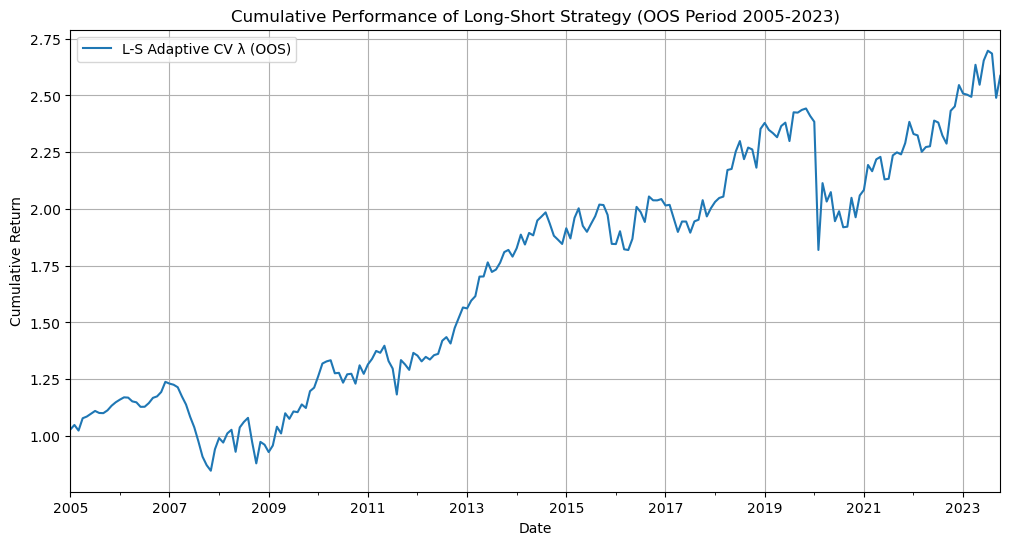


  Mean Monthly Rank IC: 0.0178
  Std Dev of Monthly Rank IC: 0.1310
  IC Sharpe (Mean/Std): 0.14


C:\Users\Admin\AppData\Local\Temp\ipykernel_76456\1329728324.py:121: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rank_ic_series = df_results_oos.groupby('date').apply(calculate_rank_ic)


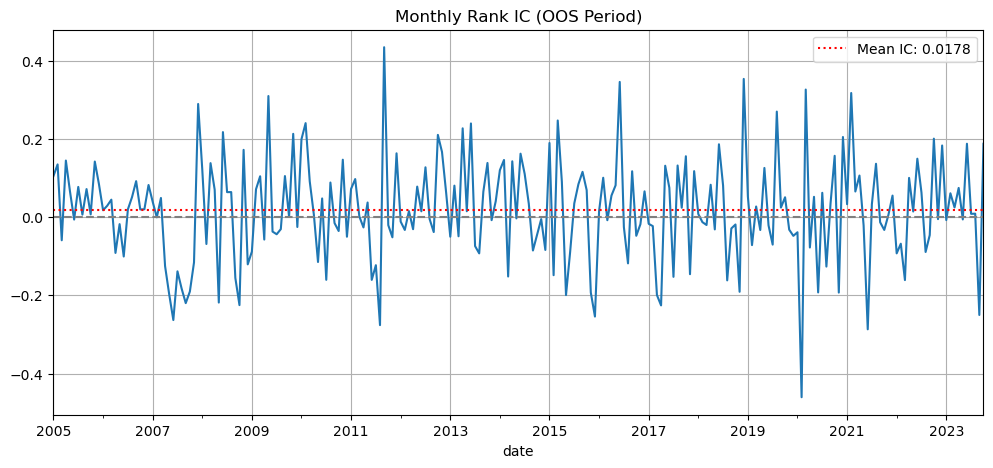


LASSO OOS Test Period Analysis Complete.


In [14]:
print("\n--- Starting LASSO Out-of-Sample (OOS) Test Period (Predicting for 2005-2023) ---")
print("Using Adaptive CV λ Strategy (Yearly Re-tuning on Expanding Window)")

oos_predict_years = range(oos_test_start_date.year, oos_test_end_date.year + 1)

results_oos_adaptive_cv = [] 
alphas_chosen_oos = [] 

alphas_to_try = np.logspace(-5, 1, 100) 
cv_splitter = TimeSeriesSplit(n_splits=5)

for year_to_predict in oos_predict_years:
    print(f"\nProcessing OOS for year to predict: {year_to_predict}")
    
    current_train_end_date = pd.to_datetime(f"{year_to_predict-1}-12-31")
    # Training data expands from the very beginning
    current_train_df = df[(df['date'] >= train_start_date) & (df['date'] <= current_train_end_date)].copy()
    
    current_test_start_date = pd.to_datetime(f"{year_to_predict}-01-31")
    current_test_end_date = pd.to_datetime(f"{year_to_predict}-12-31")
    current_test_df = df[(df['date'] >= current_test_start_date) & (df['date'] <= current_test_end_date)].copy()

    if current_train_df.empty or current_test_df.empty:
        print(f"Skipping {year_to_predict}: not enough data for train or test.")
        alphas_chosen_oos.append({'year': year_to_predict, 'alpha': np.nan, 'num_selected_features': np.nan})
        continue

    X_current_train = current_train_df[factor_columns]
    y_current_train = current_train_df[TARGET_COL]
    X_current_test = current_test_df[factor_columns]
    y_current_test_actual = current_test_df[TARGET_COL]

    print(f"  Training on {len(X_current_train)} obs from {train_start_date.date()} to {current_train_end_date.date()}")
    
    lasso_cv_oos = LassoCV(alphas=alphas_to_try, cv=cv_splitter, random_state=year_to_predict, max_iter=10000, tol=1e-3, n_jobs=-1)
    lasso_cv_oos.fit(X_current_train, y_current_train)
    selected_alpha_oos = lasso_cv_oos.alpha_
    
    model_oos = Lasso(alpha=selected_alpha_oos, random_state=year_to_predict, max_iter=10000, tol=1e-3)
    model_oos.fit(X_current_train, y_current_train)
    num_selected_features = np.sum(model_oos.coef_ != 0)
    alphas_chosen_oos.append({'year': year_to_predict, 'alpha': selected_alpha_oos, 'num_selected_features': num_selected_features})
    print(f"    Optimal λ for predicting {year_to_predict}: {selected_alpha_oos:.6f}, Selected Features: {num_selected_features}")
    
    predictions_oos = model_oos.predict(X_current_test)
    results_oos_adaptive_cv.append(pd.DataFrame({'date': current_test_df['date'],
                                                 'permno': current_test_df['permno'],
                                                 'actual_ret': y_current_test_actual,
                                                 'predicted_ret_adaptive_cv': predictions_oos}))

# --- Consolidate and Evaluate Results for OOS Test Period ---
print("\n--- Evaluating LASSO Performance on OOS Test Period (2005-2023) ---")

if results_oos_adaptive_cv:
    df_results_oos = pd.concat(results_oos_adaptive_cv, ignore_index=True)
    
    # 1. Overall MSE and OOS R^2
    mse_oos = mean_squared_error(df_results_oos['actual_ret'], df_results_oos['predicted_ret_adaptive_cv'])
    # For OOS R2, benchmark is often the mean of the target variable from the *initial* training period (1965-1989)
    # Or, more rigorously, an expanding window historical mean. For consistency with validation, use initial train mean.
    if 'y_train_initial' in locals() and y_train_initial is not None and not y_train_initial.empty:
         mean_benchmark_ret = y_train_initial.mean()
    else: # Fallback if y_train_initial is not available, use mean of all actual returns in test set (less ideal for OOS R2)
         print("Warning: y_train_initial not found for OOS R2 benchmark. Using mean of test set actuals (less comparable).")
         mean_benchmark_ret = df_results_oos['actual_ret'].mean()

    r2_oos = 1 - (np.sum((df_results_oos['actual_ret'] - df_results_oos['predicted_ret_adaptive_cv'])**2) / 
                  np.sum((df_results_oos['actual_ret'] - mean_benchmark_ret)**2))
    print(f"Adaptive CV Strategy OOS (2005-2023):")
    print(f"  Overall MSE: {mse_oos:.6f}")
    print(f"  Overall OOS R2 (vs initial train mean benchmark): {r2_oos:.4f}")

    # 2. Plot chosen alphas and number of features over time for OOS period
    df_alphas_oos = pd.DataFrame(alphas_chosen_oos)
    
    fig, ax1 = plt.subplots(figsize=(12,6))
    ax1.plot(df_alphas_oos['year'], df_alphas_oos['alpha'], marker='o', color='tab:blue', label='Selected Alpha (λ)')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Selected Alpha (λ)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_yscale('log')
    ax1.grid(True, axis='x')
    
    ax2 = ax1.twinx() # instantiate a second axes that shares the same x-axis
    ax2.plot(df_alphas_oos['year'], df_alphas_oos['num_selected_features'], marker='x', color='tab:red', linestyle='--', label='Num. Selected Features')
    ax2.set_ylabel('Number of Selected Features', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    
    plt.title('Optimal λ and Number of Selected Features Over Time (OOS Period 2005-2023)')
    fig.tight_layout() # otherwise the right y-label is slightly clipped
    # To add legends from both axes:
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='best')
    plt.show()

    # 3. Portfolio Sort Analysis for OOS period
    ls_returns_oos, quant_returns_oos = evaluate_portfolio_strategy(df_results_oos, 
                                                                    'predicted_ret_adaptive_cv', 
                                                                    'Adaptive CV λ (OOS 2005-2023)')
    if ls_returns_oos is not None:
        print("\n--- Summary for OOS Long-Short Strategy (2005-2023) ---")
        mean_ls_oos = ls_returns_oos.mean()
        sharpe_ls_oos = (mean_ls_oos / ls_returns_oos.std()) * np.sqrt(12) if ls_returns_oos.std() !=0 else 0
        print(f"  Mean Monthly L-S Return: {mean_ls_oos:.4%}")
        print(f"  Annualized L-S Sharpe Ratio: {sharpe_ls_oos:.2f}")

        plt.figure(figsize=(12,6))
        (1 + ls_returns_oos).cumprod().plot(label='L-S Adaptive CV λ (OOS)', legend=True)
        plt.title('Cumulative Performance of Long-Short Strategy (OOS Period 2005-2023)')
        plt.ylabel('Cumulative Return')
        plt.xlabel('Date')
        plt.grid(True)
        plt.show()
        
        # 4. Information Coefficient (IC) - Example for Rank IC
        def calculate_rank_ic(group):
            # Spearman rank correlation between predictions and actuals for that date
            return group['predicted_ret_adaptive_cv'].corr(group['actual_ret'], method='spearman')

        rank_ic_series = df_results_oos.groupby('date').apply(calculate_rank_ic)
        mean_rank_ic = rank_ic_series.mean()
        std_rank_ic = rank_ic_series.std()
        ic_sharpe = (mean_rank_ic / std_rank_ic) # Not typically annualized for monthly ICs, but shows consistency
        
        print(f"\n  Mean Monthly Rank IC: {mean_rank_ic:.4f}")
        print(f"  Std Dev of Monthly Rank IC: {std_rank_ic:.4f}")
        print(f"  IC Sharpe (Mean/Std): {ic_sharpe:.2f}")

        plt.figure(figsize=(12,5))
        rank_ic_series.plot(title='Monthly Rank IC (OOS Period)', legend=False)
        plt.axhline(0, color='grey', linestyle='--')
        plt.axhline(mean_rank_ic, color='red', linestyle=':', label=f'Mean IC: {mean_rank_ic:.4f}')
        plt.legend()
        plt.grid(True)
        plt.show()
        
else:
    print("No OOS results to evaluate.")

print("\nLASSO OOS Test Period Analysis Complete.")


In [1]:
print(ls_returns_oos.std())

NameError: name 'ls_returns_oos' is not defined

**Overall Assessment of LASSO Performance:**

    -The LASSO model, with adaptive CV tuning, demonstrates some positive out-of-sample predictive ability for US stock returns during 2005-2023.

    -The performance is not as strong as in the validation period, which is expected. This highlights the challenge of out-of-sample prediction in financial markets.

    -The L-S portfolio generates positive returns with a modest Sharpe ratio.

    -The IC analysis confirms a weak but positive predictive signal.

**Is this "good" performance?**

Academic Context: In academic literature, results like these (positive L-S returns, Sharpe around 0.4-0.7, small positive ICs OOS) for a systematic strategy are often publishable, especially if the methodology is sound and the economic intuition is clear. The bar for "significance" isn't necessarily a Sharpe ratio of 2+ OOS for long-short equity using broad characteristics.

Real-World Trading: After considering transaction costs, a strategy with a 0.43 Sharpe and 0.5% monthly L-S return would likely not be profitable unless turnover is extremely low or execution is perfect. However, your goal is academic research and understanding predictability, not necessarily deploying a live trading strategy.

What to do for your Thesis:

Report these OOS results clearly. Highlight both the positive aspects (positive L-S returns, positive mean IC) and the challenges (lower performance than validation, imperfect monotonicity, IC volatility).

Discuss the potential reasons for the drop in performance from validation to OOS: market regime changes, model limitations, inherent difficulty of stock return prediction.

Analyze the selected features: Which factors were most consistently selected by LASSO during this OOS period? Does this provide any economic insights? (The plot of num_selected_features over time would be useful here).

This LASSO result now serves as a benchmark. Your Decision Tree and especially your Bayesian MCMC models will be compared against this. The key question for your thesis is whether those more complex models (especially the Bayesian one designed for feature selection) can:

Improve upon this OOS performance (e.g., higher Sharpe, more consistent IC).

Provide more stable or interpretable feature selection.

Offer better risk characteristics for the L-S portfolios.